In [58]:
import json
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [59]:
records = []
base_dir = Path("../testing/")
folders = ["1_1_test", "4_4_test", "8_8_test"]

for folder_name in folders:
    folder_path = base_dir / folder_name
    if not folder_path.exists():
        continue

    setup_match = re.match(r"(\d+_\d+)_test", folder_name)
    matrix_setup = setup_match.group(1) if setup_match else folder_name

    for json_file in folder_path.glob("*_test.json"):
        test_type = json_file.stem.replace("_test", "")

        with open(json_file, "r") as f:
            data = json.load(f)

        for code_version, vec_dict in data.items():
            for vec_size, runs in vec_dict.items():
                if not runs:
                    continue

                for run in runs:
                    records.append({
                        "matrix_number": matrix_setup,
                        "matrix_dim": test_type,
                        "version": code_version,
                        "vec": int(vec_size),
                        "kernel_ms": run.get("kernel_ms"),
                        "h2d_ms": run.get("h2d_ms"),
                        "d2h_ms": run.get("d2h_ms"),
                        "cpu_post_ms": run.get("cpu_post_ms"),
                        "effective_bw": run.get("effective_bw"),
                        "useful_threads": run.get("useful_threads")
                    })

df_testing = pd.DataFrame(records)
df_testing.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads
262,4_4,large,2_gpu_naive,1,79.038,94.849,20.041,224.770,30.566,268435456
535,8_8,medium,2_gpu_naive,16,93.152,72.265,8.530,231.692,25.935,16777216
3,1_1,small,1_cpu_baseline,1,0.749,NaN,NaN,NaN,NaN,1048576
436,8_8,small,4_gpu_reduce_batch,4,3.359,0.880,0.003,0.000,39.953,16777216
134,1_1,medium,2_gpu_naive,1,1.306,2.231,0.180,3.403,28.914,4194304


In [60]:
time_cols = ['kernel_ms', 'h2d_ms', 'd2h_ms', 'cpu_post_ms']

df_testing['total_ms'] = df_testing[time_cols].sum(axis=1)
df_testing['total_ms'] = df_testing['total_ms'].round(3)

df_testing.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms
317,4_4,large,4_gpu_reduce_batch,16,13.243,9.914,0.003,0.000,40.540,16777216,23.160
452,8_8,large,2_gpu_naive,1,294.422,332.787,73.617,833.931,32.823,1073741824,1534.757
189,1_1,medium,4_gpu_reduce_batch,16,0.083,0.368,0.002,0.000,101.424,262144,0.453
539,8_8,medium,3_gpu_reduce,1,67.419,68.766,0.582,0.025,31.853,268435456,136.792
133,1_1,medium,2_gpu_naive,1,1.577,2.328,0.170,3.604,23.938,4194304,7.679


In [61]:
idx_best = df_testing.groupby(['matrix_number', 'matrix_dim', 'version', 'vec'])['total_ms'].idxmin()

df_best = df_testing.loc[idx_best].copy()

df_best['vec'] = df_best['vec'].astype(int)
df_best = df_best.sort_values(by=['version', 'vec']).reset_index(drop=True)

df_best.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms
82,1_1,medium,3_gpu_reduce,8,1.067,2.139,0.009,0.000,31.462,524288,3.215
85,4_4,medium,3_gpu_reduce,8,16.824,19.397,0.137,0.002,31.911,8388608,36.360
99,1_1,large,4_gpu_reduce_batch,1,3.210,2.114,0.002,0.000,10.452,16777216,5.326
5,4_4,small,1_cpu_baseline,1,7.115,NaN,NaN,NaN,NaN,16777216,7.115
81,1_1,large,3_gpu_reduce,8,3.954,9.790,0.010,0.000,33.947,2097152,13.754


In [62]:
cpu_mask = df_best['version'] == '1_cpu_baseline'

cpu_total_baseline  = df_best[cpu_mask].groupby(['matrix_number', 'matrix_dim'])['total_ms'].min()

dim_index = df_best.set_index(['matrix_number', 'matrix_dim']).index
df_best['cpu_total_baseline_ms']  = dim_index.map(cpu_total_baseline)

df_best['speedup_ker'] = (df_best['cpu_total_baseline_ms'] / df_best['kernel_ms']).round(3)
df_best['speedup_e2e'] = (df_best['cpu_total_baseline_ms'] / df_best['total_ms']).round(3)

df_best.sample(5)

,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms,cpu_total_baseline_ms,speedup_ker,speedup_e2e
12,4_4,large,2_gpu_naive,1,74.586,90.692,18.743,200.091,32.391,268435456,384.112,111.724,1.498,0.291
101,1_1,small,4_gpu_reduce_batch,1,0.228,0.109,0.002,0.000,9.199,1048576,0.339,0.741,3.250,2.186
19,1_1,medium,2_gpu_naive,2,1.487,2.273,0.118,3.413,25.383,2097152,7.291,2.773,1.865,0.380
57,4_4,large,3_gpu_reduce,1,64.837,93.709,0.190,0.001,33.121,268435456,158.737,111.724,1.723,0.704
18,1_1,large,2_gpu_naive,2,4.607,9.423,1.116,12.773,32.778,8388608,27.919,10.137,2.200,0.363


In [63]:
import matplotlib.pyplot as plt
import numpy as np


def plot_speedup(
    df, target_matrix_number, target_matrix_dim
):
    mask = (df["matrix_number"] == target_matrix_number) & (
        df["matrix_dim"] == target_matrix_dim
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = []
    for _, row in df_filtered.iterrows():
        if "cpu" in str(row["version"]).lower():
            labels.append("CPU")
        else:
            labels.append(f"{row['version']} v{row['vec']}")

    su_ker = df_filtered["speedup_ker"].to_numpy()
    su_e2e = df_filtered["speedup_e2e"].to_numpy()

    x = np.arange(len(labels))
    width = 0.38

    fig, ax = plt.subplots(figsize=(15, 6))

    rects1 = ax.bar(
        x - width / 2, su_ker, width, label="Speed-up Kernel", color="#1f77b4"
    )
    rects2 = ax.bar(
        x + width / 2,
        su_e2e,
        width,
        label="Speed-up End-to-End",
        color="#ff7f0e",
    )

    ax.set_ylabel("Speed-up (x)")
    ax.set_title(
        f"Confronto Speed-up (Kernel vs End-to-End) rispetto a CPU Baseline [{target_matrix_number}, {target_matrix_dim}]"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.legend(frameon=True)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if np.isnan(height):
                continue
            ax.annotate(
                f"{height:.1f}x",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

In [64]:
import matplotlib.pyplot as plt
import numpy as np


def plot_time_breakdown(
    df, target_matrix_number, target_matrix_dim
):
    mask = (df["matrix_number"] == target_matrix_number) & (
        df["matrix_dim"] == target_matrix_dim
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = []
    for _, row in df_filtered.iterrows():
        if "cpu" in str(row["version"]).lower():
            labels.append("CPU Baseline")
        else:
            labels.append(f"{row['version']} (v{row['vec']})")

    if "total_ms" in df_filtered.columns:
        cpu_mask = df_filtered["version"].str.contains("cpu", case=False, na=False)
        needs_fallback = cpu_mask & (df_filtered["kernel_ms"].fillna(0.0) == 0.0)
        df_filtered.loc[needs_fallback, "kernel_ms"] = df_filtered.loc[
            needs_fallback, "total_ms"
        ]

    h2d = df_filtered["h2d_ms"].fillna(0.0).to_numpy()
    kernel = df_filtered["kernel_ms"].fillna(0.0).to_numpy()
    d2h = df_filtered["d2h_ms"].fillna(0.0).to_numpy()
    cpu_post = df_filtered["cpu_post_ms"].fillna(0.0).to_numpy()

    x = np.arange(len(labels))
    width = 0.55

    fig, ax = plt.subplots(figsize=(15, 6))

    p_h2d = ax.bar(
        x,
        h2d,
        width,
        label="Host-to-Device (H2D)",
        color="#3498db",
    )
    p_ker = ax.bar(
        x,
        kernel,
        width,
        bottom=h2d,
        label="Kernel Execution",
        color="#2ecc71",
    )
    p_d2h = ax.bar(
        x,
        d2h,
        width,
        bottom=h2d + kernel,
        label="Device-to-Host (D2H)",
        color="#e67e22",
    )
    p_cpu = ax.bar(
        x,
        cpu_post,
        width,
        bottom=h2d + kernel + d2h,
        label="CPU Post-Processing",
        color="#e74c3c",
    )

    total_time = h2d + kernel + d2h + cpu_post

    for idx, total in enumerate(total_time):
        if total > 0:
            ax.annotate(
                f"{total:.2f} ms",
                xy=(x[idx], total),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
            )

    ax.set_ylabel("Tempo di esecuzione (ms)")
    ax.set_title(
        f"Breakdown dei Tempi di Esecuzione per Versione [{target_matrix_number}, {target_matrix_dim}]"
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)

    handles, legend_labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        legend_labels[::-1],
        frameon=True,
        loc="upper right",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

In [65]:
def plot_gpu_bandwidth(
    df,
    target_matrix_number,
    target_matrix_dim,
    peak_bandwidth_gbs=None,
):
    
    mask = (
        (df["matrix_number"] == target_matrix_number)
        & (df["matrix_dim"] == target_matrix_dim)
        & (~df["version"].str.contains("cpu", case=False, na=False))
    )
    df_filtered = df[mask].copy()

    if df_filtered.empty:
        print(
            f"Nessun dato GPU trovato per matrix_number='{target_matrix_number}' e matrix_dim='{target_matrix_dim}'"
        )
        return

    df_filtered = df_filtered.sort_values(by=["version", "vec"]).reset_index(
        drop=True
    )

    labels = [
        f"{row['version']}\n(v{row['vec']})"
        for _, row in df_filtered.iterrows()
    ]
    bw_vals = df_filtered["effective_bw"].to_numpy()

    x = np.arange(len(labels))
    width = 0.55

    fig, ax = plt.subplots(figsize=(14, 6))

    colors = []
    for ver in df_filtered["version"]:
        if "naive" in ver.lower():
            colors.append("#e74c3c")
        elif "batch" in ver.lower():
            colors.append("#2ecc71")
        else:
            colors.append("#3498db")

    rects = ax.bar(
        x,
        bw_vals,
        width,
        color=colors,
        edgecolor="#2c3e50",
        linewidth=0.8,
        alpha=0.9,
    )

    if peak_bandwidth_gbs is not None:
        ax.axhline(
            peak_bandwidth_gbs,
            color="#e67e22",
            linestyle="--",
            linewidth=1.5,
            label=f"Peak BW Teorica ({peak_bandwidth_gbs} GB/s)",
            alpha=0.85,
        )

    for rect in rects:
        height = rect.get_height()
        if np.isnan(height) or height == 0:
            continue

        ax.annotate(
            f"{height:.1f} GB/s",
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            rotation=25,
        )

    ax.set_ylabel("Bandwidth Effettiva (GB/s)", fontsize=11)
    ax.set_title(
        f"Confronto Bandwidth Effettiva tra Versioni GPU [{target_matrix_number}, {target_matrix_dim}]",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)

    y_max = np.nanmax(bw_vals)
    if peak_bandwidth_gbs:
        y_max = max(y_max, peak_bandwidth_gbs)
    ax.set_ylim(0, y_max * 1.18)

    if peak_bandwidth_gbs is not None:
        ax.legend(frameon=True, loc="upper left")

    ax.grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

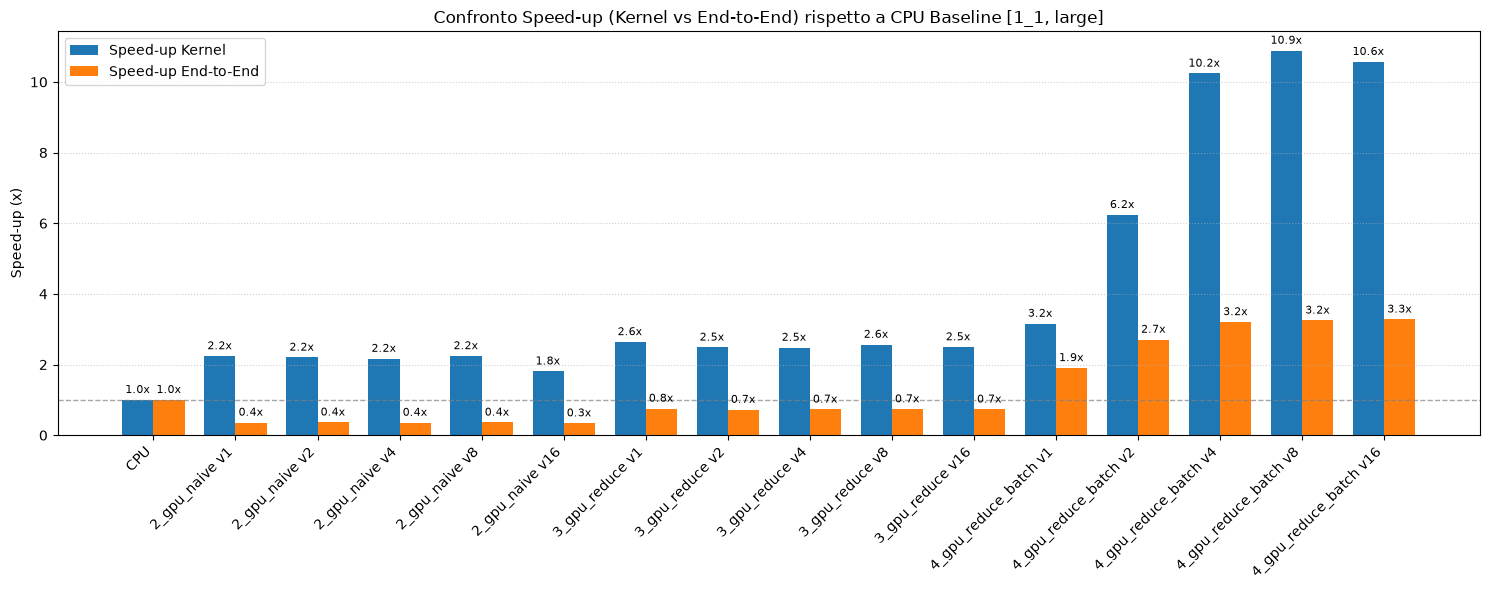

In [66]:
plot_speedup(df_best, target_matrix_number="1_1", target_matrix_dim="large")

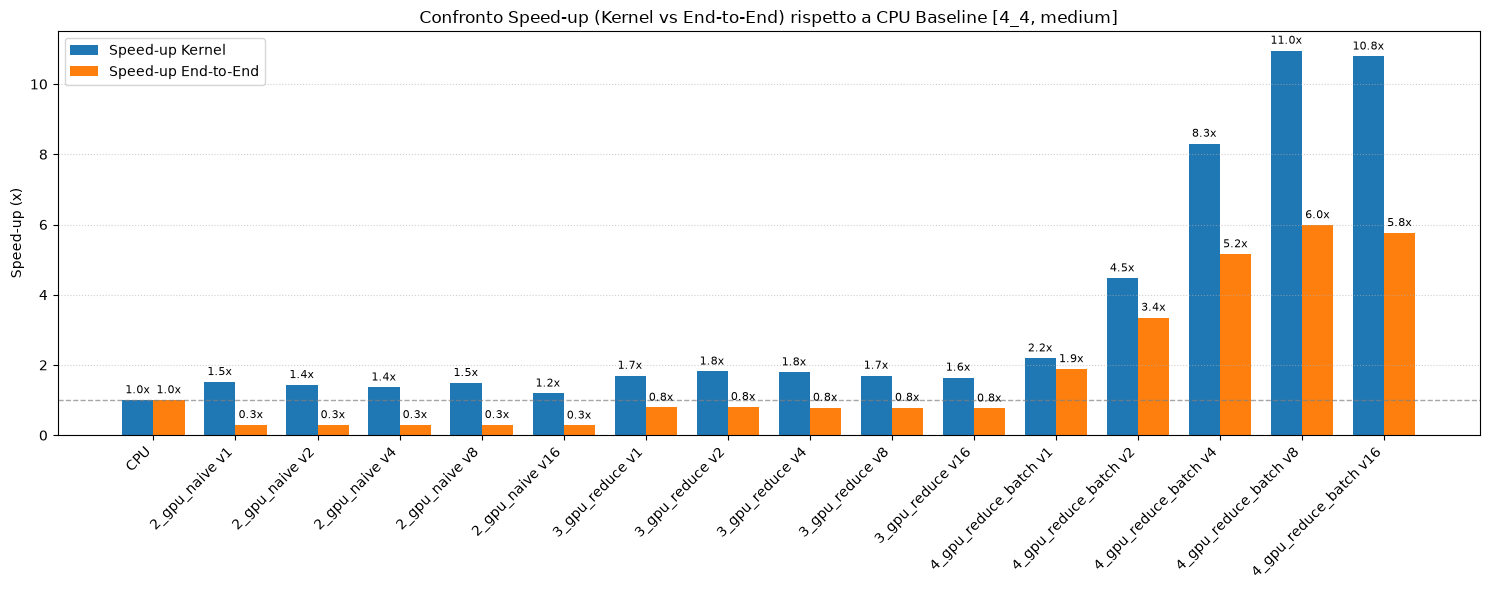

In [67]:
plot_speedup(df_best, target_matrix_number="4_4", target_matrix_dim="medium")


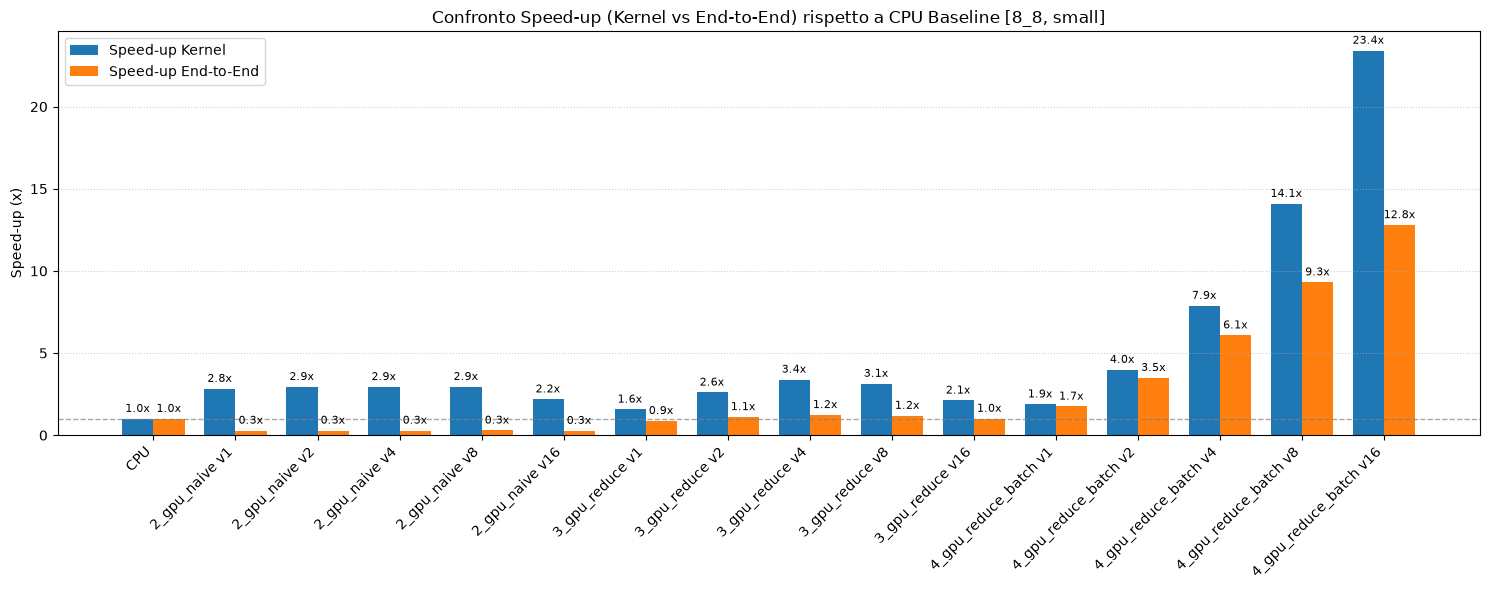

In [68]:
plot_speedup(df_best, target_matrix_number="8_8", target_matrix_dim="small")

In [69]:
df_best.head()


,matrix_number,matrix_dim,version,vec,kernel_ms,h2d_ms,d2h_ms,cpu_post_ms,effective_bw,useful_threads,total_ms,cpu_total_baseline_ms,speedup_ker,speedup_e2e
0,1_1,large,1_cpu_baseline,1,10.137,NaN,NaN,NaN,NaN,16777216,10.137,10.137,1.0,1.0
1,1_1,medium,1_cpu_baseline,1,2.773,NaN,NaN,NaN,NaN,4194304,2.773,2.773,1.0,1.0
2,1_1,small,1_cpu_baseline,1,0.741,NaN,NaN,NaN,NaN,1048576,0.741,0.741,1.0,1.0
3,4_4,large,1_cpu_baseline,1,111.724,NaN,NaN,NaN,NaN,268435456,111.724,111.724,1.0,1.0
4,4_4,medium,1_cpu_baseline,1,28.578,NaN,NaN,NaN,NaN,67108864,28.578,28.578,1.0,1.0


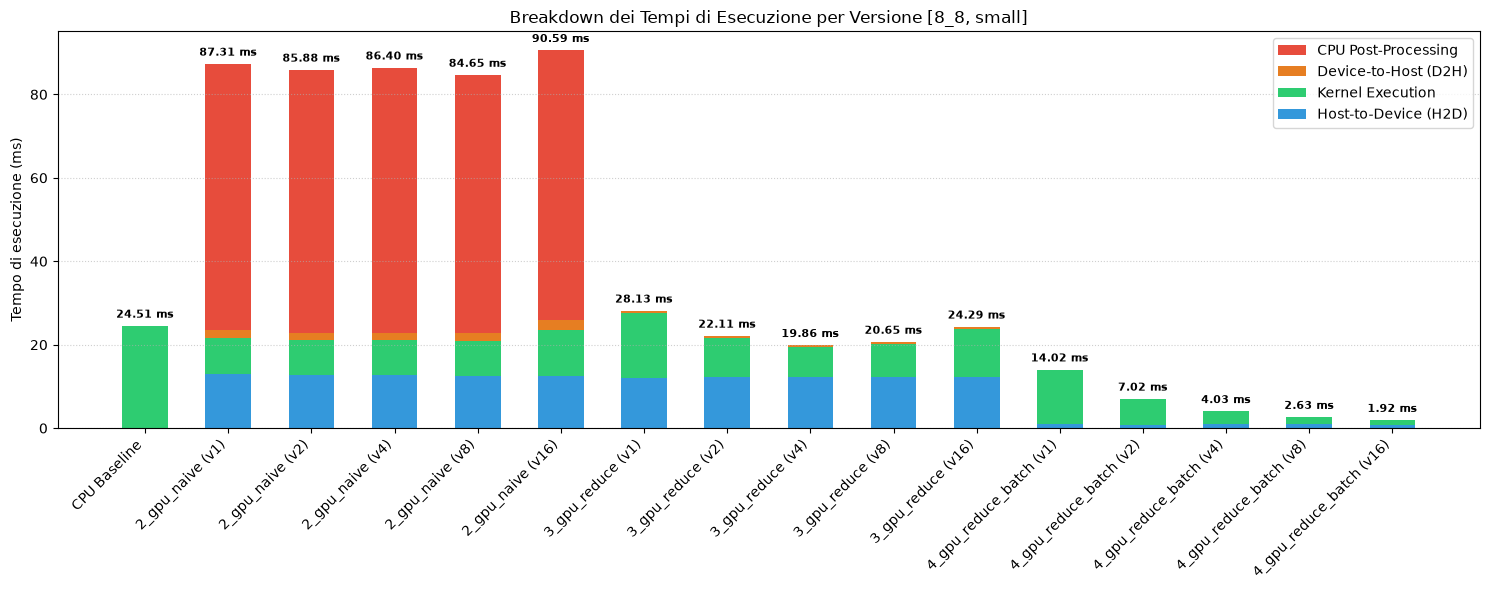

In [70]:
plot_time_breakdown(df_best, "8_8", "small")

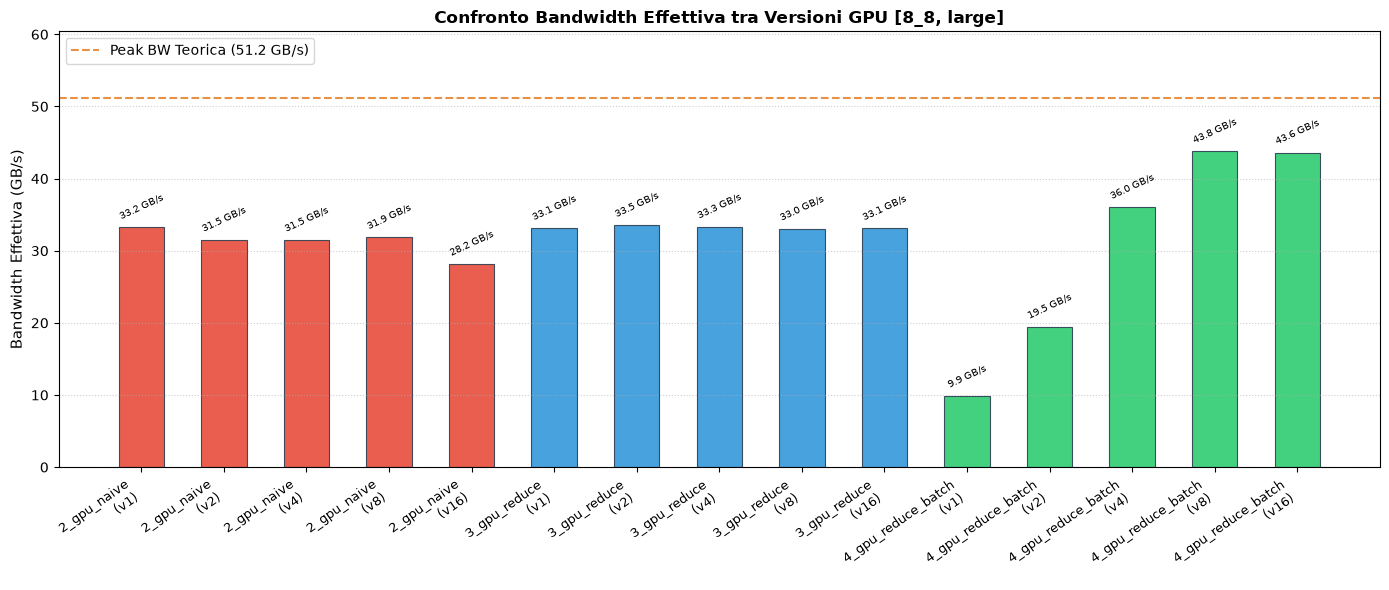

In [71]:
peak_memory_bw = 51.2

plot_gpu_bandwidth(df_best, "8_8", "large", peak_memory_bw)